In [18]:


import zipfile

zip_path = "/content/sample_data/processed.zip"
extract_path = "/content/processed"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [19]:
import os
import time
import json
import torch
import torchvision
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from datetime import timedelta
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")


In [20]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import gc


In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
from collections import defaultdict

image_size = 128
batch_size = 128
sample_size = 50000
epochs = 50

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)

classes_to_keep = ['food', 'drink', 'inside', 'outside']
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_name = full_dataset.classes[label]
    if class_name in classes_to_keep:
        class_indices[class_name].append(idx)

sample_per_class = sample_size // len(classes_to_keep)
final_indices = []
for cls in classes_to_keep:
    cls_indices = class_indices[cls]
    if len(cls_indices) < sample_per_class:
        raise ValueError(f"Not enough samples in class '{cls}' to sample {sample_per_class}")
    final_indices.extend(random.sample(cls_indices, sample_per_class))

# Create a mapping from original class indices to new class indices
original_to_new_idx = {class_to_idx[cls]: i for i, cls in enumerate(classes_to_keep)}

# Create a custom dataset that applies the new class mapping
class MappedSubset(Subset):
    def __init__(self, dataset, indices, transform=None):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        new_label = original_to_new_idx[label]
        if self.transform:
            image = self.transform(image)
        return image, new_label

dataset = MappedSubset(full_dataset, final_indices, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print("Classes used:", classes_to_keep)
print(f"Total samples used: {len(dataset)}")
print(f"Samples per class: {sample_per_class}")

Classes used: ['food', 'drink', 'inside', 'outside']
Total samples used: 50000
Samples per class: 12500


In [22]:
# === Generator ===
class Generator(nn.Module):
    def __init__(self, classes_to_keep, z_dim=100):
        super().__init__()
        self.label_embed = nn.Embedding(len(classes_to_keep), z_dim)
        self.model = nn.Sequential(
            nn.Linear(z_dim * 2, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 3 * 64 * 64),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_embed(labels)
        x = torch.cat([z, label_embedding], dim=1)
        out = self.model(x)
        return out.view(-1, 3, 64, 64)

In [11]:
# === Discriminator ===
class Discriminator(nn.Module):
    def __init__(self, classes_to_keep):
        super().__init__()
        self.label_embed = nn.Embedding(len(classes_to_keep), 3 * 64 * 64)
        self.model = nn.Sequential(
            nn.Linear(2 * 3 * 64 * 64, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_embedding = self.label_embed(labels)
        img_flat = img.view(img.size(0), -1)
        d_input = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(d_input)

In [13]:
# === Dataset Loading ===
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)
subset_indices = list(range(min(10000, len(dataset))))
dataset = Subset(dataset, subset_indices)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, pin_memory=True)

In [14]:
# === Model Setup ===
z_dim = 100
classes_to_keep = ["food", "drink", "inside", "outside", "people"]
num_classes = len(classes_to_keep)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(classes_to_keep, z_dim=z_dim).to(device)
D = Discriminator(classes_to_keep).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(num_classes, z_dim).to(device)
fixed_labels = torch.arange(num_classes).to(device)


In [15]:
# === Train Loop ===
epochs = 10
os.makedirs("generated_samples", exist_ok=True)

for epoch in range(epochs):
    start_time = time.time()

    for real_imgs, labels in dataloader:
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        batch_size = real_imgs.size(0)

        # === Train Discriminator ===
        z = torch.randn(batch_size, z_dim).to(device)
        fake_imgs = G(z, labels)

        real_loss = criterion(D(real_imgs, labels), torch.ones((batch_size, 1), device=device))
        fake_loss = criterion(D(fake_imgs.detach(), labels), torch.zeros((batch_size, 1), device=device))
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # === Train Generator ===
        g_loss = criterion(D(fake_imgs, labels), torch.ones((batch_size, 1), device=device))

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    end_time = time.time()
    print(f"📆 Epoch {epoch+1}/{epochs} | ✅ Gen Loss: {g_loss.item():.4f} | Disc Loss: {d_loss.item():.4f} | 🕒 Time: {end_time - start_time:.2f}s")

    # Save sample images every 2 epochs
    if (epoch + 1) % 2 == 0:
        with torch.no_grad():
            gen_imgs = G(fixed_noise, fixed_labels).detach().cpu()
            grid = utils.make_grid(gen_imgs, nrow=num_classes, normalize=True)
            utils.save_image(grid, f"generated_samples/epoch_{epoch+1}.png")

    # Clear GPU cache and memory fragments
    torch.cuda.empty_cache()
    gc.collect()

📆 Epoch 1/10 | ✅ Gen Loss: 1.2515 | Disc Loss: 0.5054 | 🕒 Time: 55.05s
📆 Epoch 2/10 | ✅ Gen Loss: 1.4201 | Disc Loss: 0.6475 | 🕒 Time: 53.91s
📆 Epoch 3/10 | ✅ Gen Loss: 1.0254 | Disc Loss: 0.7405 | 🕒 Time: 54.06s
📆 Epoch 4/10 | ✅ Gen Loss: 1.7091 | Disc Loss: 0.6420 | 🕒 Time: 54.85s
📆 Epoch 5/10 | ✅ Gen Loss: 1.5059 | Disc Loss: 0.6465 | 🕒 Time: 54.01s
📆 Epoch 6/10 | ✅ Gen Loss: 1.5949 | Disc Loss: 0.3652 | 🕒 Time: 53.84s
📆 Epoch 7/10 | ✅ Gen Loss: 0.7584 | Disc Loss: 0.7388 | 🕒 Time: 53.86s
📆 Epoch 8/10 | ✅ Gen Loss: 1.4633 | Disc Loss: 0.5589 | 🕒 Time: 53.97s
📆 Epoch 9/10 | ✅ Gen Loss: 1.8595 | Disc Loss: 0.3893 | 🕒 Time: 53.75s
📆 Epoch 10/10 | ✅ Gen Loss: 1.4882 | Disc Loss: 0.4352 | 🕒 Time: 54.02s


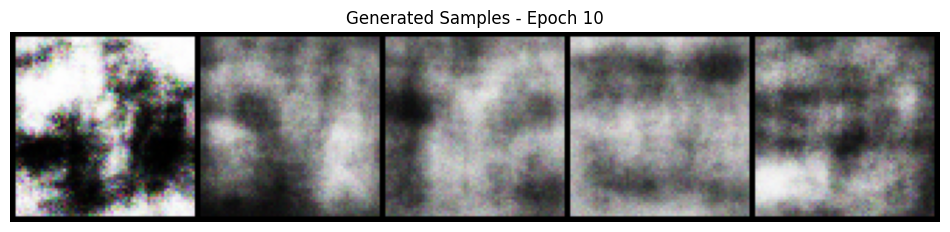

In [20]:
 # Display in Colab
import numpy as np
npimg = grid.numpy()
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis('off')
plt.title(f"Generated Samples - Epoch {epoch+1}")
plt.show()